 Part 1: Create a custom multi-armed bandit environment that follows the Gymnasium API structure (implement reset() and step() methods). The bandit should have 10 arms with Gaussian reward distributions. Implement ε-greedy and UCB algorithms as agents using NumPy for numerical computations. Run 2000 time steps across 1000 independent runs. Plot average reward and optimal action percentage over time for each algorithm with multiple parameter settings (try ε ∈ {0.01, 0.1, 0.2} and different UCB confidence levels).

In [ ]:
import numpy as np

class GaussianBandit:
    def __init__(self, n_arms=10):
        self.n_arms = n_arms
        self.reset()

    def reset(self):
        self.q_star = np.random.normal(0, 1, self.n_arms)
        self.optimal_arm = np.argmax(self.q_star)
        return None  # No state needed

    def step(self, action):
        reward = np.random.normal(self.q_star[action], 1)
        done = False
        return None, reward, done, {}

In [2]:
class EpsilonGreedyAgent:
    def __init__(self, n_arms, epsilon):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.n_arms)
        self.counts = np.zeros(self.n_arms)

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)
        return np.argmax(self.Q)

    def update(self, action, reward):
        self.counts[action] += 1
        step_size = 1 / self.counts[action]
        self.Q[action] += step_size * (reward - self.Q[action])

In [3]:
class UCBAgent:
    def __init__(self, n_arms, c):
        self.n_arms = n_arms
        self.c = c
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.n_arms)
        self.counts = np.zeros(self.n_arms)
        self.total_steps = 0

    def select_action(self):
        self.total_steps += 1

        # Explore all actions at least once
        for a in range(self.n_arms):
            if self.counts[a] == 0:
                return a

        ucb_values = self.Q + self.c * np.sqrt(
            np.log(self.total_steps) / self.counts
        )
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.counts[action] += 1
        step_size = 1 / self.counts[action]
        self.Q[action] += step_size * (reward - self.Q[action])

In [4]:
def run_simulation(agent_type, param, runs=1000, steps=2000):
    rewards = np.zeros((runs, steps))
    optimal_actions = np.zeros((runs, steps))

    for run in range(runs):
        env = GaussianBandit()
        env.reset()

        if agent_type == "egreedy":
            agent = EpsilonGreedyAgent(10, param)
        else:
            agent = UCBAgent(10, param)

        agent.reset()

        for t in range(steps):
            action = agent.select_action()
            _, reward, _, _ = env.step(action)

            agent.update(action, reward)

            rewards[run, t] = reward
            optimal_actions[run, t] = (action == env.optimal_arm)

    return rewards.mean(axis=0), optimal_actions.mean(axis=0)

In [ ]:
epsilons = [0.01, 0.1, 0.2]
ucb_cs = [0.5, 1, 2]

results = {}

# ε-greedy
for eps in epsilons:
    avg_r, opt = run_simulation("egreedy", eps)
    results[f"ε={eps}"] = (avg_r, opt)

# UCB
for c in ucb_cs:
    avg_r, opt = run_simulation("ucb", c)
    results[f"UCB c={c}"] = (avg_r, opt)

In [ ]:
import matplotlib.pyplot as plt

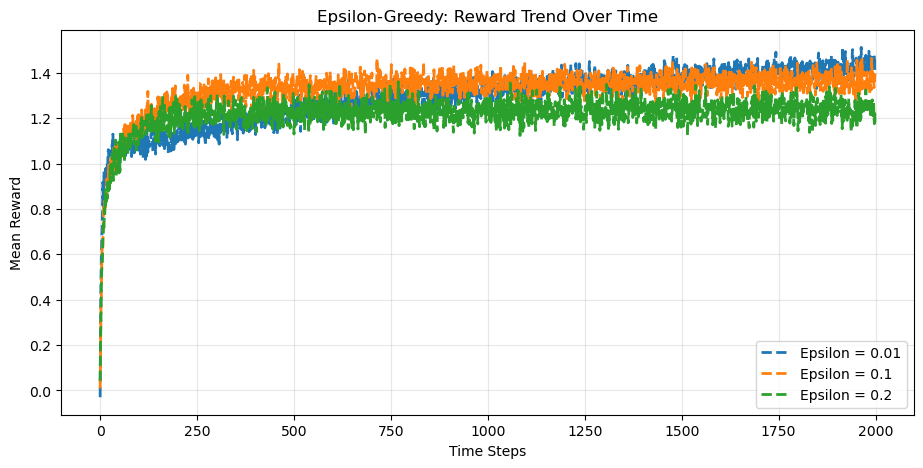

In [8]:
plt.figure(figsize=(11,5))

for eps in [0.01, 0.1, 0.2]:
    avg_r, _ = results[f"ε={eps}"]
    plt.plot(avg_r, linestyle='--', linewidth=2, label=f"Epsilon = {eps}")

plt.title("Epsilon-Greedy: Reward Trend Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Mean Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The reward goes up pretty quickly in the beginning as the agent starts figuring out which arms are better. With ε = 0.01, it learns fast but can get stuck early since it doesn’t explore much. ε = 0.1 feels more balanced and gives more consistent results over time. On the other hand, ε = 0.2 explores a lot, so it’s a bit slower at first. Overall, a middle value like 0.1 works best because it balances trying new things and sticking with good choices.

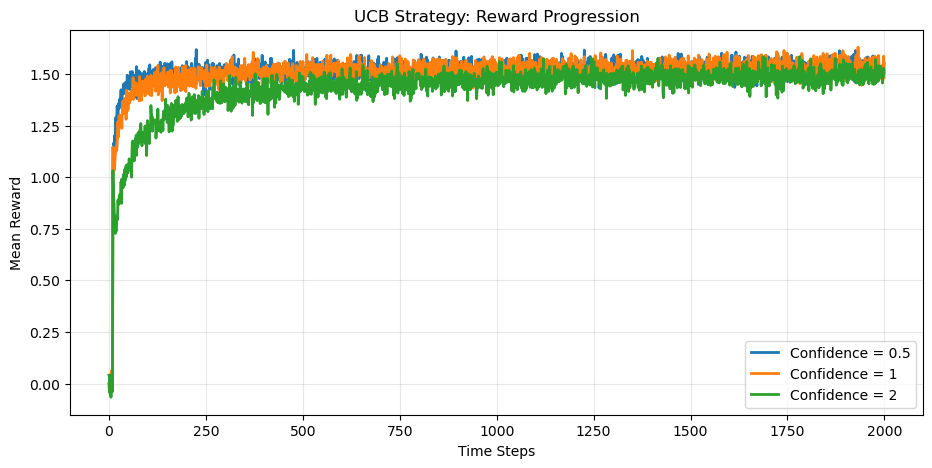

In [9]:
plt.figure(figsize=(11,5))

for c in [0.5, 1, 2]:
    avg_r, _ = results[f"UCB c={c}"]
    plt.plot(avg_r, linewidth=2, label=f"Confidence = {c}")

plt.title("UCB Strategy: Reward Progression")
plt.xlabel("Time Steps")
plt.ylabel("Mean Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The reward increases quickly at the beginning as the agent explores different arms and learns which ones are better. With lower confidence values like c = 0.5, the agent settles faster and reaches higher rewards early. c = 1 also performs well and stays consistent over time. However, with c = 2, the agent explores more, so it learns a bit slower in the beginning. Overall, smaller(0.5)  or moderate(1) values of c tend to give better performance because they balance exploration without overdoing it.

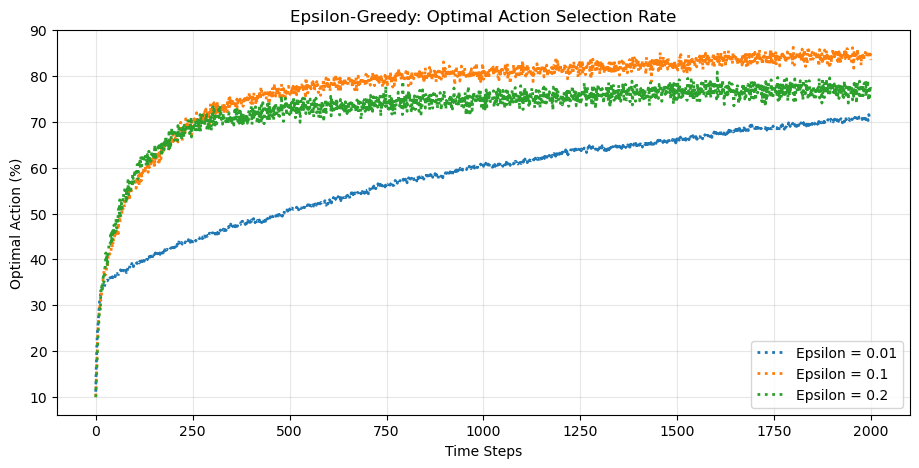

In [10]:
plt.figure(figsize=(11,5))

for eps in [0.01, 0.1, 0.2]:
    _, opt = results[f"ε={eps}"]
    plt.plot(opt * 100, linestyle=':', linewidth=2, label=f"Epsilon = {eps}")

plt.title("Epsilon-Greedy: Optimal Action Selection Rate")
plt.xlabel("Time Steps")
plt.ylabel("Optimal Action (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The percentage of selecting the optimal action increases quickly at the start as the agent learns which arm is best. ε = 0.1 performs the best overall, reaching the highest optimal action rate and staying consistent. ε = 0.2 also learns fast but levels off slightly lower due to more exploration. ε = 0.01 improves more slowly since it explores less in the beginning. Overall, a moderate ε gives the best long-term performance.

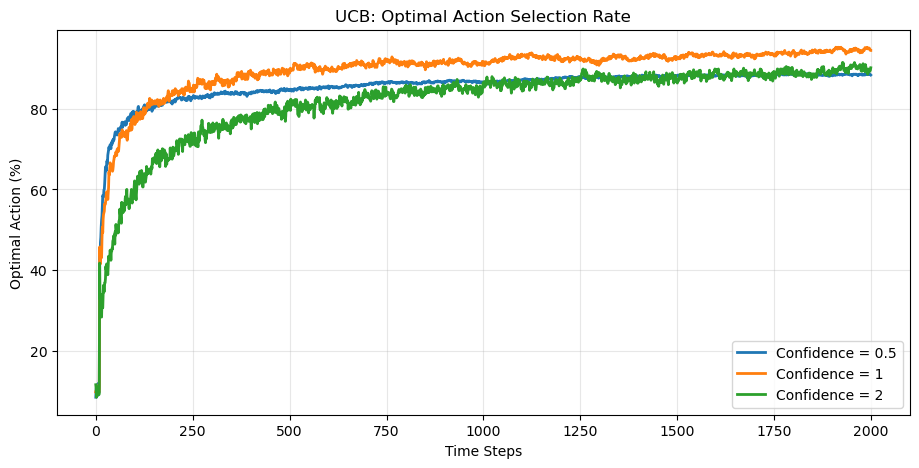

In [11]:
plt.figure(figsize=(11,5))

for c in [0.5, 1, 2]:
    _, opt = results[f"UCB c={c}"]
    plt.plot(opt * 100, linewidth=2, label=f"Confidence = {c}")

plt.title("UCB: Optimal Action Selection Rate")
plt.xlabel("Time Steps")
plt.ylabel("Optimal Action (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The optimal action rate increases quickly at the beginning as the agent explores and identifies the best arm. The setting with c = 1 performs the best overall, reaching the highest percentage and staying consistent. c = 0.5 also does well but is slightly lower since it explores less. On the other hand, c = 2 improves more slowly because it explores more, which delays finding the best action. Overall, a moderate value like c = 1 gives the best balance and performance.

Part 2: Explore Gymnasium’s standard environments (FrozenLake-v1, Taxi-v3). Write code to inspect their observation and action spaces (discrete vs. continuous, dimensions, bounds). Implement a random policy agent and measure its performance. Document how the MDP tuple (S, A, R, P, γ) maps to Gymnasium’s API. Your implementation should be modular with separate agent classes that interact with environments through the standard interface.

In [12]:
import gymnasium as gym

env_list = ["FrozenLake-v1", "Taxi-v3"]

for env_name in env_list:
    env = gym.make(env_name)

    print(f"\n--- {env_name} ---")
    print("State Space:", env.observation_space)
    print("Action Space:", env.action_space)

    env.close()


--- FrozenLake-v1 ---
State Space: Discrete(16)
Action Space: Discrete(4)

--- Taxi-v3 ---
State Space: Discrete(500)
Action Space: Discrete(6)


In [13]:
class RandomPolicy:
    def __init__(self, action_space):
        self.action_space = action_space

    def choose_action(self, state):
        return self.action_space.sample()

In [14]:
import numpy as np

def test_random_policy(env_name, episodes=10):
    env = gym.make(env_name)
    agent = RandomPolicy(env.action_space)

    episode_rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.choose_action(state)
            state, reward, terminated, truncated, _ = env.step(action)

            total_reward += reward
            done = terminated or truncated

        episode_rewards.append(total_reward)

    env.close()

    avg_reward = np.mean(episode_rewards)
    print(f"{env_name}: Average Reward over {episodes} episodes = {avg_reward:.2f}")

In [15]:
test_random_policy("FrozenLake-v1")
test_random_policy("Taxi-v3")

FrozenLake-v1: Average Reward over 10 episodes = 0.00
Taxi-v3: Average Reward over 10 episodes = -808.40


In FrozenLake-v1, the random agent gets an average reward of 0.0, which shows it almost never reaches the goal. This happens because the environment is slippery and unpredictable, and rewards are very sparse, so random actions don’t help much. In Taxi-v3, the agent performs even worse, with an average reward around –808, mainly due to constant penalties from wrong moves and inefficient actions in a large state space.

These results make it clear that random behavior isn’t enough for environments that need step-by-step decision making. Unlike the bandit problem, these tasks require understanding the environment and planning actions. This also shows why smarter strategies like ε-greedy and UCB perform much better, since they balance exploration with learning from past actions.